# SmolVLM2 Streaming Inference - Version 2: ProAssist-Style

This notebook implements streaming inference using SmolVLM2 model that mimics the behavior of ProAssist model's streaming inference. The model is forced to generate something at each assistant turn from the dataset sample, similar to the original ProAssist implementation.

Key features:
- Uses SmolVLM2 model instead of ProAssist
- External context management with summarization when context limit is reached
- 4:1 aspect ratio resizing for optimal image encoding
- Prints processed contexts and compares generated vs reference responses
- True Streaming inference with speaking decision prediciton at each frame using the probability of w2t special token with token id 49191
- Adjustable speaking decision threshold: model will generate assistant response when the probaility of w2t token is lower than threshold, otherwise the model will not do anything
- Automatic Summarization: When context exceeds 7.5k tokens, uses SmolVLM2 to summarize and reset context
- Format Conversion: Converts ProAssist dataset format to SmolVLM2's chat template format

## Setup and Model Loading

In [ ]:
%%capture
# !pip install torch torchvision Pillow transformers==4.55.4 datasets matplotlib accelerate
!pip install --no-deps --upgrade timm

In [1]:
import torch
import json
from dataclasses import dataclass, asdict
from PIL import Image
from transformers import AutoProcessor, Idefics3ForConditionalGeneration
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import numpy as np
from typing import List, Dict, Any, Optional, Tuple
import pprint

# Import ProAssist components for dataset loading
from mmassist.model import build_from_checkpoint
from mmassist.configs.arguments import EvalArguments
from mmassist.eval.eval_utils import parse_inference_setups
from mmassist.data import build_train_dataset, build_eval_datasets
from mmassist.configs.arguments import DATA_ROOT_DIR
from mmassist.data.utils import tensor_to_pil_images

/u/swong2/.conda/envs/smolvlm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Load fine-tuned SmolVLM2 model from checkpoint
# model_checkpoint = "/u/swong2/ProAssist/smolvlm-proassist-finetune-smalltest/"

# Load original base model
model_checkpoint = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"
# model_checkpoint = "HuggingFaceTB/SmolVLM2-500M-Video-Instruct"

print(f"Loading fine-tuned SmolVLM2 model from: {model_checkpoint}")
smol_model = Idefics3ForConditionalGeneration.from_pretrained(
    model_checkpoint,
    dtype=torch.bfloat16,
    device_map="auto"
).eval()

smol_processor = AutoProcessor.from_pretrained(model_checkpoint)
# Load LoRA adapter checkpoint
from peft import PeftModel

lora_checkpoint = "/u/swong2/ProAssist/mmassist/train/finetune_jobs/finetune_smolvlm2_2B_wtag/checkpoint-500"
# lora_checkpoint = "/u/swong2/ProAssist/mmassist/train/finetune_jobs/finetune_smolvlm2_500M_wtag_8/checkpoint-500"
print(f"Loading LoRA adapter from: {lora_checkpoint}")
smol_model = PeftModel.from_pretrained(smol_model, lora_checkpoint)
print("LoRA adapter loaded successfully")

print(f"Fine-tuned model loaded on device: {smol_model.device}")
print(f"Max context length: {getattr(smol_model.config, 'max_position_embeddings', 'Not found')}")

You are using a model of type smolvlm to instantiate a model of type idefics3. This is not supported for all configurations of models and can yield errors.


Loading fine-tuned SmolVLM2 model from: HuggingFaceTB/SmolVLM2-2.2B-Instruct


Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 9310.33it/s]


Loading LoRA adapter from: /u/swong2/ProAssist/mmassist/train/finetune_jobs/finetune_smolvlm2_2B_wtag/checkpoint-500
LoRA adapter loaded successfully
Fine-tuned model loaded on device: cuda:0
Max context length: Not found


## Load ProAssist Dataset

In [36]:
# Load the same dataset used in ProAssist streaming inference
inference_setups = "wtag/dialog-klg_val_L0_I1|stream|4k|0.5|summarize_and_drop"
eval_args = EvalArguments(model_path="dummy", inference_setups=inference_setups)

DATA_ROOT_DIR = "/projects/beto/proassist_data"

# Build dataset configuration
class DummyConfig:
    def __init__(self):
        self.data_root_dir = f"{DATA_ROOT_DIR}/processed_data"
        self.training_args = {
            "data_root_dir": f"{DATA_ROOT_DIR}/processed_data",
            "eval_datasets": inference_setups.split("|")[0]
        }
    
    def to_dict(self):
        return {
            "data_root_dir": self.data_root_dir,
            **self.training_args
        }

config = DummyConfig()
all_args_dict = config.to_dict()
# all_args_dict["eval_datasets"] = "wtag/dialog-klg-sum_val_L2048_I1"
all_args_dict["eval_datasets"] = "wtag/dialog-klg_test_L0_I1"
print(all_args_dict)

print("Loading dataset...")
dataset_dict = build_eval_datasets(**all_args_dict, print_info=True, keep_images=True)
datasets = list(dataset_dict.values())
dataset = datasets[0]

print(f"Dataset loaded with {len(dataset)} samples")

{'data_root_dir': '/projects/beto/proassist_data/processed_data', 'eval_datasets': 'wtag/dialog-klg_test_L0_I1'}
Loading dataset...
Evaluation datasets:
* wtag/dialog-klg_test | num samples: 21

Dataset loaded with 21 samples


=== Sample 10 ===
Video ID: T52
Number of images: 1416

=== Conversation ===
1. [SYSTEM]: You are a proactive assistant. Predict the user's needs and provide assistance before being requested.
2. [FRAMES]: 0 - 13
3. [USER]: I want to make a mug cake.
4. [SYSTEM]: Task knowledge: Mug Cake

Ingredients
2 Tablespoons all-purpose flour
1.5 Tablespoons granulated sugar
1/4 teaspoon baking powder
Pinch salt
2 teaspoons canola or vegetable oil
2 Tablespoons water
1/4 teaspoon vanilla extract
Container of chocolate frosting (premade)

Tools and Utensils
measuring spoons small mixing bowl whisk
paper cupcake liner 12-ounce coffee mug plate
microwave
zip-top bag, snack or sandwich size scissors
spoon
toothpick

Steps
1. Place the paper cupcake liner inside the mug. Set aside.
2. Measure and add the flour, sugar, baking powder, and salt to the mixing bowl.
3. Whisk to combine.
4. Measure and add the oil, water, and vanilla to the bowl.
5. Whisk batter until no lumps remain.
6. Pour batter into pr

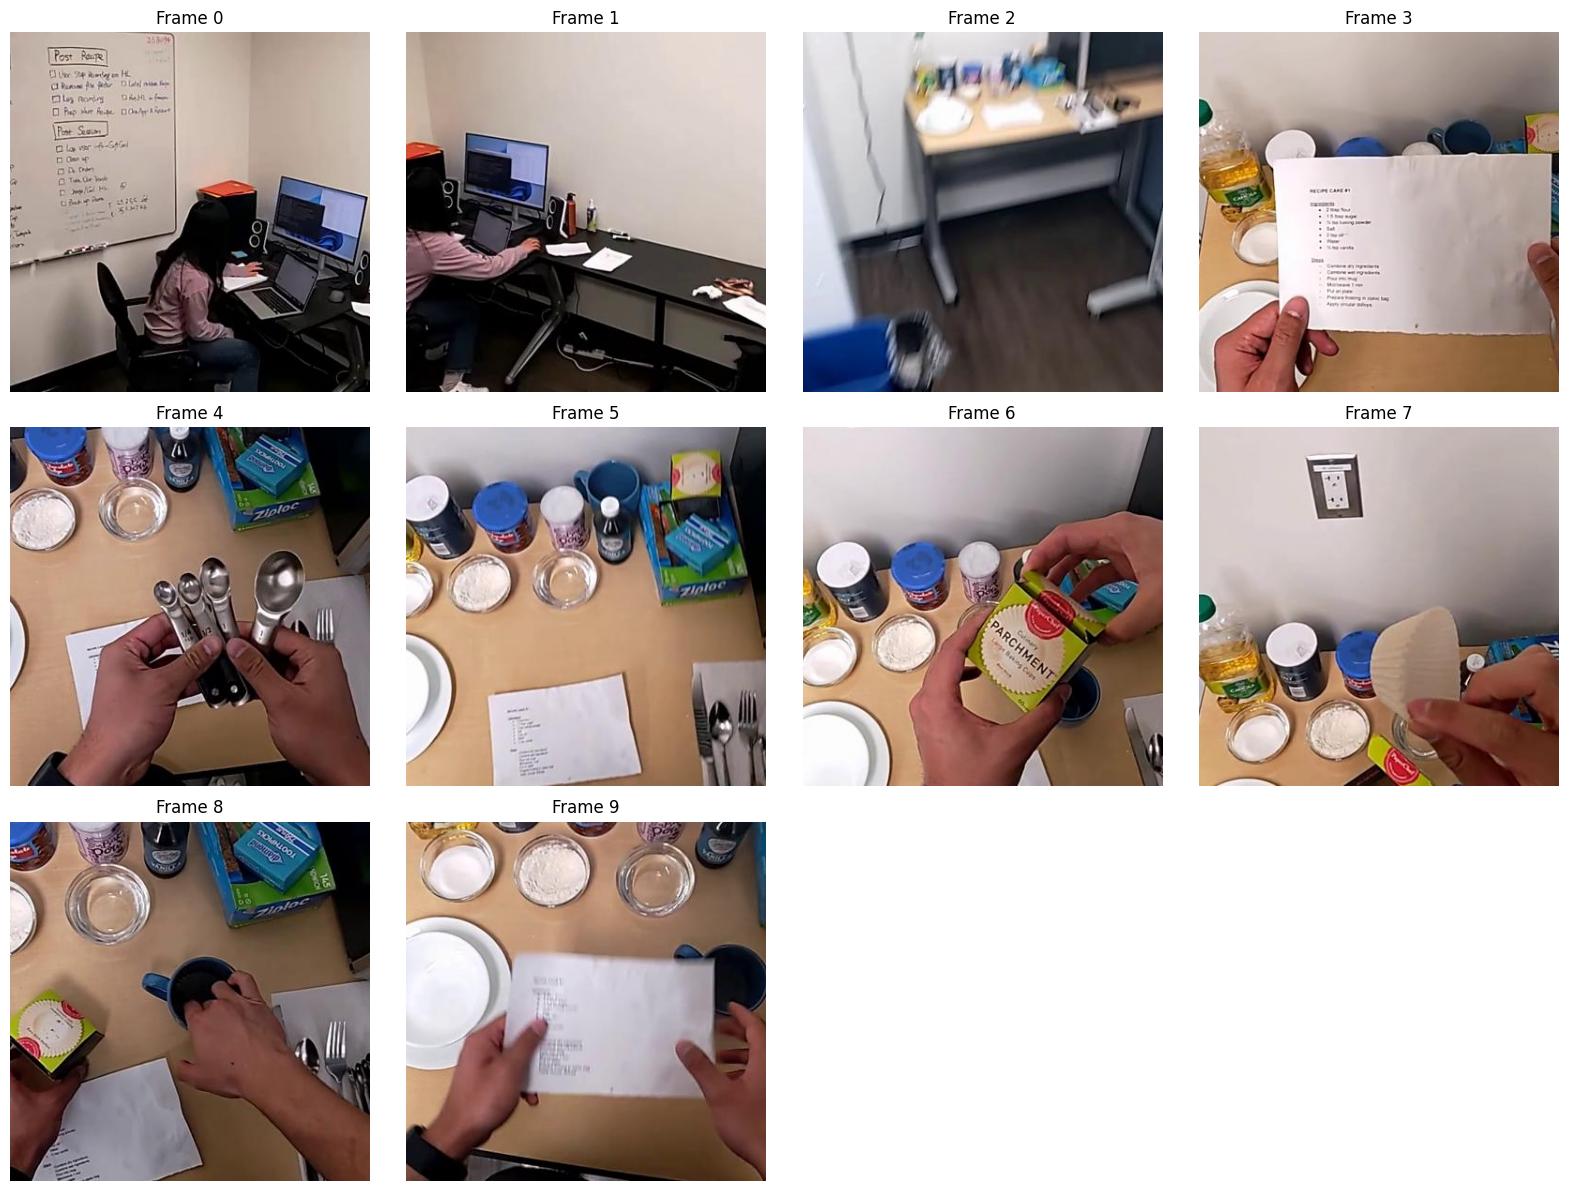

In [42]:
def display_sample_with_frames(dataset, sample_idx=0, max_frames_to_show=10):
    """Display a sample from the dataset with its frames and conversation."""
    
    sample = dataset[sample_idx]
    
    print(f"=== Sample {sample_idx} ===")
    print(f"Video ID: {sample.get('video_uid', 'N/A')}")
    print(f"Number of images: {len(sample.get('images', []))}")
    
    # Display conversation
    if 'conversation' in sample:
        print("\n=== Conversation ===")
        for i, conv in enumerate(sample['conversation']):
            role = conv.get('role', 'unknown')
            if role == "frames":
                content = f"{conv['start']} - {conv['end']}"
            else:
                content = conv.get('content', '')
            print(f"{i+1}. [{role.upper()}]: {content}")
    
    # Display frames
    images = sample.get('images', [])
    if images != []:
        n_display = min(max_frames_to_show, len(images))
        print(f"\n=== Displaying {n_display} frames ===")
        
        cols = 4
        rows = (n_display + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        for i in range(n_display):
            row, col = i // cols, i % cols
            ax = axes[row, col]
            
            # Convert image to displayable format
            img = images[i*10] # for smaller fps
            img_norm = (img - img.min()) / (img.max() - img.min())
            img_np = img_norm.permute(1, 2, 0).detach().cpu().numpy()
            
            ax.imshow(img_np)
            ax.set_title(f'Frame {i}')
            ax.axis('off')
        
        # Hide empty subplots
        for i in range(n_display, rows * cols):
            row, col = i // cols, i % cols
            axes[row, col].axis('off')
        
        plt.tight_layout()
        plt.show()

# Display the first sample
display_sample_with_frames(dataset, sample_idx=10)

## SmolVLM2 Stream Processor and Runner

In [38]:
@dataclass
class SmolVLM2FrameInput:
    """input unit for context-aware SmolVLM2 streaming inference."""
    current_image: Image.Image  # Current frame image
    frame_idx_in_stream: int
    frame_idx_in_original_video: int
    timestamp: float
    ref_output_str: Optional[str] = None
    accumulated_user_messages: List[str] = None  # User message(s) right before this frame

@dataclass
class SmolVLM2FrameOutput:
    """per-frame output from SmolVLM2 streaming inference."""
    gen: str
    ref: Optional[str] = None
    current_image: Optional[Image.Image] = None
    frame_idx_in_stream: Optional[int] = None
    frame_idx_in_original_video: Optional[int] = None
    timestamp_in_stream: Optional[float] = None
    context_length: Optional[int] = None
    image_tokens_used: Optional[int] = None

    def to_dict(self, ignore_keys: str | list[str] = "current_image") -> dict:
        ret = asdict(self)
        if ignore_keys:
            if isinstance(ignore_keys, str):
                ignore_keys = [ignore_keys]
            for k in ignore_keys:
                ret.pop(k, None)
        return ret

In [39]:
class SmolVLM2StreamProcessor:
    """processor for context-aware SmolVLM2 streaming inference."""
    
    def __init__(self, processor, fps: int = 2, use_4_1_aspect_ratio: bool = True):
        self.processor = processor
        self.fps = fps
        self.use_4_1_aspect_ratio = use_4_1_aspect_ratio
    
    def resize_image_for_optimal_encoding(self, image: Image.Image) -> Image.Image:
        """Resize image to 4:1 aspect ratio for optimal SmolVLM2 encoding."""
        if not self.use_4_1_aspect_ratio:
            return image
        
        # Calculate target dimensions maintaining 4:1 ratio
        # Use 384 as base width (common in vision models)
        target_width = 384
        target_height = target_width // 4  # 4:1 ratio
        
        return image.resize((target_width, target_height), Image.Resampling.LANCZOS)

    def _fix_task_knowledge(self, sample):
        """Fix task knowledge placement in system messages."""
        conversation = sample["conversation"].copy()
        task_knowledge = f"Task knowledge: {sample['metadata']['knowledge']}"

        # Find and process system messages
        first_system_idx = None
        second_system_idx = None

        for i, turn in enumerate(conversation):
            if turn["role"] == "system":
                if first_system_idx is None:
                    first_system_idx = i
                else:
                    second_system_idx = i
                    break

        # Remove second system turn if it contains "Task knowledge: "
        if (
            second_system_idx is not None
            and "Task knowledge: " in conversation[second_system_idx]["content"]
        ):
            conversation.pop(second_system_idx)

        # Add task knowledge to first system turn if not already present
        first_system_content = conversation[first_system_idx]["content"]
        if "Task knowledge: " not in first_system_content:
            conversation[first_system_idx][
                "content"
            ] = f"{first_system_content} {task_knowledge}"

        # Create updated sample
        updated_sample = sample.copy()
        updated_sample["conversation"] = conversation
        return updated_sample
    
    def processed_conv_data_to_stream(self, video: Dict) -> Tuple[List[SmolVLM2FrameInput], str]:
        """Convert ProAssist video data to stream format with proper conversation flow."""
        # Step 1: fix task knowledge for proassist sample
        video = self._fix_task_knowledge(video)

        conversation = video["conversation"]
        frame_index_offset = video["start_frame_idx"]
        images = video.get("images", None)
        
        if images is None:
            raise ValueError("Images are required for SmolVLM2 streaming inference")
        
        # Step 2: Process conversation sequentially
        frame_streams = []
        accumulated_user_messages = []  # Messages accumulated so far
        
        for turn_idx, turn in enumerate(conversation):
            if turn["role"] == "system":
                combined_system_prompt = turn["content"]

            elif turn["role"] == "user":
                # Add user message to accumulated context
                accumulated_user_messages.append(turn["content"])
                
            elif turn["role"] == "frames":
                # Process frames in this segment
                start = turn["start"] - frame_index_offset
                end = turn["end"] - frame_index_offset
                
                # Get reference output for the last frame in this segment
                ref_output_str = None
                if turn_idx < len(conversation) - 1:
                    next_turn = conversation[turn_idx + 1]
                    if next_turn["role"] == "assistant":
                        ref_output_str = next_turn["content"]

                # TODO: could add frame sampling here to go from 2fps to 0.2fps

                # Sample frames based on sampling ratio
                num_frames = max(0, min(end, len(images)) - max(0, start))
                sampled_frame_count = min(max(
                    1, int(num_frames * 0.1) # frame_sampling_ratio = 0.1
                ), 22)

                step = max(1, num_frames // sampled_frame_count)
                frame_indices = list(range(start, min(end, len(images)), step))[
                    :sampled_frame_count
                ]
                
                for k in frame_indices:
                    # Convert image tensor to PIL
                    pt_img = images[k : k + 1]
                    pil_img = tensor_to_pil_images(pt_img)[0]
                    
                    # resize for optimal encoding
                    pil_img = self.resize_image_for_optimal_encoding(pil_img)
                    
                    # Create frame input (messages will be built later with full context)
                    time = (len(frame_streams) + 1) / self.fps
                    
                    # Reference output only for the last frame in segment
                    frame_ref = ref_output_str if k == frame_indices[-1] else None
                    
                    frame = SmolVLM2FrameInput(
                        current_image=pil_img,
                        frame_idx_in_stream=len(frame_streams),
                        frame_idx_in_original_video=k + frame_index_offset,
                        timestamp=time,
                        ref_output_str=frame_ref,
                        accumulated_user_messages=accumulated_user_messages.copy()
                    )
                    
                    frame_streams.append(frame)

                    # Only the first frame in the segment gets the new user messages, so reset
                    accumulated_user_messages = []
        
        return frame_streams, combined_system_prompt

In [40]:
class SmolVLM2StreamRunner:
    """streaming inference runner with full context awareness for SmolVLM2."""
    
    def __init__(self, model, processor, fps: int = 2, max_context_tokens: int = 7500, use_4_1_aspect_ratio: bool = True):
        self.model = model
        self.processor = processor
        self.fps = fps
        self.max_context_tokens = max_context_tokens  # Reduced for 16k context window
        self.stream_processor = SmolVLM2StreamProcessor(processor, fps, use_4_1_aspect_ratio)
        self.image_token_id = processor.tokenizer.additional_special_tokens_ids[
            processor.tokenizer.additional_special_tokens.index("<image>")]
        
        # Enhanced context management
        self.conversation_history = []  # List of message dicts
        self.frame_history = []  # List of images
        
        # Summary agent system message
        self.summary_agent_prompt = """Please summarize the progress."""
    
    def print_conversation_history(self, max_content_length: int = 100):
        """Print conversation history in a nicely formatted way.
        
        Args:
            max_content_length: Maximum length of content to display before truncating
        """
        print("\n" + "="*80)
        print("Conversation History")
        print("="*80)
        
        if not self.conversation_history:
            print("(empty)")
            print("="*80 + "\n")
            return
        
        for i, turn in enumerate(self.conversation_history):
            role = turn["role"].upper()
            print(f"\n[Turn {i+1}] {role}:")
            
            for j, content_item in enumerate(turn["content"]):
                content_type = content_item["type"]
                
                if content_type == "text":
                    text = content_item["text"]
                    if len(text) > max_content_length:
                        text = text[:max_content_length] + "..."
                    print(f"  [{j+1}] Text: {text}")
                    
                elif content_type == "image":
                    # Show image info without the actual image data
                    img = content_item.get("image")
                    if img and hasattr(img, 'size'):
                        print(f"  [{j+1}] Image: {img.size[0]}x{img.size[1]}")
                    else:
                        print(f"  [{j+1}] Image: <image data>")
        
        print("\n" + "="*80 + "\n")
    
    def count_tokens_with_images(self) -> Tuple[int, int]:
        """Count tokens including both text and images in conversation_history.
        Returns (total_tokens, image_tokens)"""
        if not self.conversation_history:
            return 0, 0
        
        try:
            # Process the entire conversation to get accurate token count
            inputs = self.processor.apply_chat_template(
                self.conversation_history,
                add_generation_prompt=False,
                tokenize=True,
                return_dict=True,
                return_tensors="pt"
            )
            
            total_tokens = inputs["input_ids"].shape[-1]
            image_tokens = (inputs["input_ids"] == self.image_token_id).sum().item()
            
            return total_tokens, image_tokens
            
        except Exception as e:
            print(f"Warning: Could not count tokens accurately, using estimate: {e}")
            # Fallback estimation
            total_estimate = 0
            image_estimate = 0
            
            for turn in self.conversation_history:
                for content_item in turn["content"]:
                    if content_item["type"] == "text":
                        total_estimate += len(content_item["text"].split()) * 1.3  # Rough estimate
                    elif content_item["type"] == "image":
                        image_tokens_est = 500  # Conservative estimate
                        total_estimate += image_tokens_est
                        image_estimate += image_tokens_est
            
            return int(total_estimate), image_estimate
    
    def manage_context(self) -> bool:
        """Manage context size and return True if summarization occurred."""
        # Count current tokens
        current_tokens, image_tokens = self.count_tokens_with_images()
        
        if current_tokens > self.max_context_tokens:
            print(f"\n[CONTEXT MANAGEMENT] Token limit reached ({current_tokens} > {self.max_context_tokens}) with {image_tokens} image tokens. Generating summary...")

            # get assistant prompt/progress summary and task knowledge first system message
            assistant_and_progress, task_knowledge = self.conversation_history[0]["content"][0]["text"].split("Task knowledge: ")

            # add a system role summary prompt
            self.conversation_history.append(
                        {
                            "role": "system",
                            "content": [{"type": "text", "text": self.summary_agent_prompt}],
                        }
                    )

            # Generate summary
            summary = self.generate_response(self.conversation_history)
            print(f"[CONTEXT MANAGEMENT] Generated summary: {summary[:200]}...")
            
            # create new first system message
            new_sys_msg = assistant_and_progress + summary + "Task knowledge: " + task_knowledge
            
            # Replace conversation history with new system message 
            self.conversation_history = [
                {
                    "role": "system",
                    "content": [{"type": "text", "text": new_sys_msg}],
                }
            ]
            
            new_tokens, new_image_tokens = self.count_tokens_with_images()
            print(f"[CONTEXT MANAGEMENT] Context reset. New token count: {new_tokens} (image tokens: {new_image_tokens})")
            
            return True
        
        return False
    
    def generate_response(self, messages: List[Dict[str, Any]]) -> str:
        """Generate response using SmolVLM2 model."""
        inputs = self.processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt"
        ).to(self.model.device, dtype=torch.bfloat16)
        
        with torch.inference_mode():
            generation = self.model.generate(
                **inputs,
                do_sample=True, 
                max_new_tokens=500
            )
        
        input_len = inputs["input_ids"].shape[-1]
        response = self.processor.decode(generation[0][input_len:], skip_special_tokens=True)
        return response.strip()

    def make_speaking_decision(self, speaking_threshold: float = 0.6) -> bool:
        """
        Determine if the assistant should speak based on w2t token probability.
        
        Args:
            speaking_threshold: Threshold for speaking decision. Assistant speaks if 
                            w2t probability < threshold.
        
        Returns:
            bool: True if assistant should speak, False otherwise.
        """

        # print(f"Making speaking decision with {self.conversation_history}")

        # W2T token ID (wait-to-talk special token)
        w2t_token_id = 49279 # changed to EOS
        # w2t_token_id = 49191
        end_of_utterance_token_id = 49279
        
        try:
            # Tokenize the conversation history
            inputs = self.processor.apply_chat_template(
                self.conversation_history,
                add_generation_prompt=False,
                tokenize=True,
                return_dict=True,
                return_tensors="pt"
            ).to(self.model.device, dtype=torch.bfloat16)
            
            # Remove the last token until it is END_OF_UTTERANCE_TOKEN_ID
            input_ids = inputs["input_ids"]
            while input_ids[0, -1].item() != end_of_utterance_token_id:
                # print(f"REMOVED token: {input_ids[0, -1].item()}")
                input_ids = input_ids[:, :-1]
                # Also adjust attention mask if present
                if "attention_mask" in inputs:
                    inputs["attention_mask"] = inputs["attention_mask"][:, :-1]

            # Remove END_OF_UTTERANCE_TOKEN_ID
            input_ids = input_ids[:, :-1]

            # print(f"Last few tokens are {input_ids[0, -5:].tolist()}")

            # Update inputs with modified input_ids
            inputs["input_ids"] = input_ids
            
            # Get model output with logits
            with torch.inference_mode():
                outputs = self.model(**inputs)
                logits = outputs.logits
            
            # Get the logits for the next token (last position)
            next_token_logits = logits[0, -1, :]  # Shape: [vocab_size]
            
            # Apply softmax to get probabilities
            next_token_probs = torch.softmax(next_token_logits, dim=-1)


            # # get and print out the top 5 token probabilities
            # top_k = 5
            # top_k_probs, top_k_indices = torch.topk(next_token_probs, top_k)
            # print(f"Top token IDs: {top_k_indices.tolist()}")
            # for i in range(top_k):
            #     print(f"Token ID: {top_k_indices[i].item()}, Probability: {top_k_probs[i].item()}")

            # Get probability of w2t token
            w2t_prob = next_token_probs[w2t_token_id].item()
            
            # Assistant should speak if w2t probability is lower than threshold
            should_speak = w2t_prob < speaking_threshold
            print(f"w2t_prob: {w2t_prob}, speaking_threshold: {speaking_threshold}, should_speak: {should_speak}")

            return should_speak
            
        except Exception as e:
            print(f"Warning: Error in speaking decision, defaulting to speak: {e}")
            return True  # Default to speaking if there's an error
        
    def run_inference_on_video(self, 
                             video: Dict, 
                             verbose: bool = False,
                             max_time: int = -1) -> Dict:
        """Run enhanced context-aware streaming inference on a video."""
        
        if verbose:
            print("Preprocessing stream data...")
        
        # Get frame streams and system prompt
        streams, combined_system_prompt = self.stream_processor.processed_conv_data_to_stream(video)

        # Initialize context
        self.conversation_history = [
            {
                "role": "system",
                "content": [{"type": "text", "text": combined_system_prompt}],
            }
        ]
        
        outputs = []
        
        for frame_input in streams:

            # add each accumulated_user_messages to conversation history
            for user_message in frame_input.accumulated_user_messages:
                if self.conversation_history[-1]["role"] == "user": # latest turn is user role
                    self.conversation_history[-1]["content"].append(
                        {"type": "text", "text": user_message}
                    )
                
                else:
                    self.conversation_history.append(
                        {
                            "role": "user",
                            "content": [{"type": "text", "text": user_message}],
                        }
                    )

            # add current frame image to conversation history
            if self.conversation_history[-1]["role"] == "user": # latest turn is user role
                self.conversation_history[-1]["content"].append(
                    {"type": "image", "image": frame_input.current_image}
                )
            
            else:
                self.conversation_history.append(
                    {
                        "role": "user",
                        "content": [{"type": "image", "image": frame_input.current_image}],
                    }
                )
            
            self.print_conversation_history()

            # make speaking decision prediction
            should_speak = self.make_speaking_decision(speaking_threshold=0.6)
            
            if should_speak:
                # Generate response
                generated_response = self.generate_response(self.conversation_history)

                self.conversation_history.append(
                    {
                        "role": "assistant",
                        "content": [{"type": "text", "text": generated_response}],
                    }
                )
            else:
                # Don't generate response, just continue to next frame
                generated_response = "SILENCE"

            # Manage context size
            summarized = self.manage_context()
            
            # Count tokens for this frame
            context_tokens, image_tokens = self.count_tokens_with_images()
            
            # Create output
            output = SmolVLM2FrameOutput(
                gen=generated_response,
                ref=frame_input.ref_output_str,
                current_image=frame_input.current_image,
                frame_idx_in_stream=frame_input.frame_idx_in_stream,
                frame_idx_in_original_video=frame_input.frame_idx_in_original_video,
                timestamp_in_stream=frame_input.timestamp,
                context_length=context_tokens,
                image_tokens_used=image_tokens,
            )
            
            outputs.append(output)
            
            # Verbose output
            if verbose:
                print(f"=== Frame {frame_input.frame_idx_in_stream} ({frame_input.timestamp:.1f}s) ===")
                print(f"Context tokens: {context_tokens} (image: {image_tokens})")
                if frame_input.accumulated_user_messages:
                    for msg in frame_input.accumulated_user_messages:
                        print(f"[{frame_input.timestamp:.1f}s] USER: {msg}")
                print(f"[{frame_input.timestamp:.1f}s] REF : {frame_input.ref_output_str}")
                print(f"[{frame_input.timestamp:.1f}s] GEN : {generated_response}\n")

            # Check max time limit
            if max_time > 0 and frame_input.timestamp >= max_time:
                if verbose:
                    print(f"\nMax time reached: {max_time}s")
                break
        
        metadata = {
            "dataset": video.get("dataset", "unknown"),
            "sample_idx": video.get("sample_idx", -1),
            "video_uid": video.get("video_uid", "unknown"),
            "fps": self.fps,
            "model_type": "smolvlm2",
            "max_context_tokens": self.max_context_tokens,
            "total_frames_processed": len(outputs),
            "use_4_1_aspect_ratio": self.stream_processor.use_4_1_aspect_ratio
        }
        
        return {"metadata": metadata, "predictions": outputs}

## Run Streaming Inference

In [43]:
# Create the streaming runner
runner = SmolVLM2StreamRunner(
    model=smol_model,
    processor=smol_processor,
    fps=0.2,
    max_context_tokens=7500, 
    use_4_1_aspect_ratio=True   # Enable optimal image encoding
)

print("SmolVLM2 Stream Runner initialized")
print(f"Max context tokens: {runner.max_context_tokens}")
print(f"FPS: {runner.fps}")
print(f"Using 4:1 aspect ratio: {runner.stream_processor.use_4_1_aspect_ratio}")

# Run streaming inference on a single video (ProAssist-style)
sample_idx = 10  # Choose a sample to test
video = dataset[sample_idx]

print(f"Running streaming inference on sample {sample_idx}...")
print(f"Video ID: {video.get('video_uid', 'N/A')}")
print(f"Number of frames: {len(video.get('images', []))}")

# Run inference with verbose output
results = runner.run_inference_on_video(
    video,
    verbose=True,
    max_time=320  # Limit to 60 seconds for demo
)

print(f"\n=== INFERENCE COMPLETE ===")
print(f"Total frames processed: {len(results['predictions'])}")
print(f"Metadata: {results['metadata']}")

SmolVLM2 Stream Runner initialized
Max context tokens: 7500
FPS: 0.2
Using 4:1 aspect ratio: True
Running streaming inference on sample 10...
Video ID: T52
Number of frames: 1416
Preprocessing stream data...

Conversation History

[Turn 1] SYSTEM:
  [1] Text: You are a proactive assistant. Predict the user's needs and provide assistance before being requeste...

[Turn 2] USER:
  [1] Image: 384x96


w2t_prob: 0.9921875, speaking_threshold: 0.6, should_speak: False
=== Frame 0 (5.0s) ===
Context tokens: 869 (image: 405)
[5.0s] REF : None
[5.0s] GEN : SILENCE


Conversation History

[Turn 1] SYSTEM:
  [1] Text: You are a proactive assistant. Predict the user's needs and provide assistance before being requeste...

[Turn 2] USER:
  [1] Image: 384x96
  [2] Text: I want to make a mug cake.
  [3] Image: 384x96


w2t_prob: 0.08447265625, speaking_threshold: 0.6, should_speak: True
=== Frame 1 (10.0s) ===
Context tokens: 1364 (image: 810)
[10.0s] USER: I want to make a mug cake.
[10.0s] REF : G

KeyboardInterrupt: 

In [ ]:
fake_generated_ids = torch.tensor([[
9519
]])

fake_generated_texts = smol_processor.batch_decode(
    fake_generated_ids,
    skip_special_tokens=False,
)
print("H" + fake_generated_texts[0] + "H")

## Analysis and Comparison

In [ ]:
# Analyze the results
def analyze_streaming_results(results):
    """Analyze and display streaming inference results."""
    predictions = results['predictions']
    metadata = results['metadata']
    
    print(f"=== STREAMING INFERENCE ANALYSIS ===")
    print(f"Model: {metadata['model_type']}")
    print(f"Total frames processed: {metadata['total_frames_processed']}")
    print(f"FPS: {metadata['fps']}")
    print(f"Max context tokens: {metadata['max_context_tokens']}")
    print(f"Using 4:1 aspect ratio: {metadata.get('use_4_1_aspect_ratio', 'N/A')}")
    
    # Count frames with responses
    frames_with_responses = sum(1 for p in predictions if p.gen.strip())
    frames_with_references = sum(1 for p in predictions if p.ref and p.ref.strip())
    
    print(f"\nFrames with generated responses: {frames_with_responses}/{len(predictions)}")
    print(f"Frames with reference responses: {frames_with_references}/{len(predictions)}")
    
    # Show context length progression
    context_lengths = [p.context_length for p in predictions if p.context_length]
    image_tokens = [p.image_tokens_used for p in predictions if p.image_tokens_used]
    
    if context_lengths:
        print(f"\nContext length progression:")
        print(f"  Initial: {context_lengths[0]}")
        print(f"  Final: {context_lengths[-1]}")
        print(f"  Max: {max(context_lengths)}")
        
    if image_tokens:
        print(f"\nImage token usage:")
        print(f"  Initial: {image_tokens[0]}")
        print(f"  Final: {image_tokens[-1]}")
        print(f"  Max: {max(image_tokens)}")
    
    # Show some example comparisons
    print(f"\n=== EXAMPLE COMPARISONS ===")
    comparison_count = 0
    for i, pred in enumerate(predictions):
        if pred.ref and pred.ref.strip() and comparison_count < 3:
            print(f"\nFrame {pred.frame_idx_in_stream} ({pred.timestamp_in_stream:.1f}s):")
            print(f"  Context: {pred.context_length} tokens ({pred.image_tokens_used} image)")
            print(f"  REF: {pred.ref}")
            print(f"  GEN: {pred.gen}")
            comparison_count += 1

# Analyze the results
analyze_streaming_results(results)

## Test Multiple Samples

In [ ]:
# Test on multiple samples to see consistency
def test_multiple_samples(runner, dataset, sample_indices=[1, 2, 3], max_time=30):
    """Test streaming inference on multiple samples."""
    all_results = []
    
    for idx in sample_indices:
        print(f"\n{'='*50}")
        print(f"TESTING SAMPLE {idx}")
        print(f"{'='*50}")
        
        video = dataset[idx]
        print(f"Video ID: {video.get('video_uid', 'N/A')}")
        print(f"Number of frames: {len(video.get('images', []))}")
        
        try:
            # Reset runner state
            runner.conversation_history = []
            runner.frame_history = []
            
            results = runner.run_inference_on_video(
                video,
                verbose=False,  # Set to True for detailed output
                max_time=max_time
            )
            
            all_results.append((idx, results))
            
            # Quick summary
            predictions = results['predictions']
            frames_with_gen = sum(1 for p in predictions if p.gen.strip())
            frames_with_ref = sum(1 for p in predictions if p.ref and p.ref.strip())
            
            # Context statistics
            context_lengths = [p.context_length for p in predictions if p.context_length]
            image_tokens = [p.image_tokens_used for p in predictions if p.image_tokens_used]
            
            print(f"Processed {len(predictions)} frames")
            print(f"Generated responses: {frames_with_gen}")
            print(f"Reference responses: {frames_with_ref}")
            if context_lengths:
                print(f"Max context tokens: {max(context_lengths)}")
            if image_tokens:
                print(f"Max image tokens: {max(image_tokens)}")
            
        except Exception as e:
            print(f"Error processing sample {idx}: {e}")
            import traceback
            traceback.print_exc()
    
    return all_results

# Test multiple samples
multi_results = test_multiple_samples(runner, dataset, sample_indices=[1, 2, 3], max_time=30)